**Навигация по уроку**

1. [Краткая история нейронных сетей. Знакомство с многослойным персептроном](https://colab.research.google.com/drive/1-FEYLgNSN5kJyAOoaW9dOhDUABU8VJlc)
2. [Математический аппарат обучения нейронных сетей](https://colab.research.google.com/drive/1FtyyBXYq9FaOEknvu4ghim-ejuO_3aIZ)
3. [Обучение многослойного персептрона в TensorFlow (Практика)](https://colab.research.google.com/drive/1Q8ioc9pkkaqGravu37C7jKw9OaG7cNL0)
4. Домашняя работа

Используя модель обучения многослойного персептрона из практической части урока (9.3), выполните следующее:

1. Увеличьте число слоев до 4-х и сравните время обучения модели и точность на тестовой выборке.
2. В качестве датасета использовать любой из наборов данных TensorFlow. Обучить модель. Добейтесь результата распознования более 85% на тестовой выборке. [Датасеты на выбор](https://www.tensorflow.org/datasets/overview). Используйте датасет отличный от MNIST, который был в уроке.

Для прохождения урока достаточно решить первое задание.

In [ ]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import tempfile
import os
# Установим по умолчанию размер фигуры для Matplotlib по умолчанию.
matplotlib.rcParams['figure.figsize'] = [9, 6]

import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
train_data, val_data, test_data = tfds.load("mnist",
                                            split=['train[10000:]', 'train[0:10000]', 'test'],
                                            batch_size=128, as_supervised=True)

Размерность исходных данных: (1500, 28, 28, 1)
Размерность данных после сжатия: (1500, 28, 28)


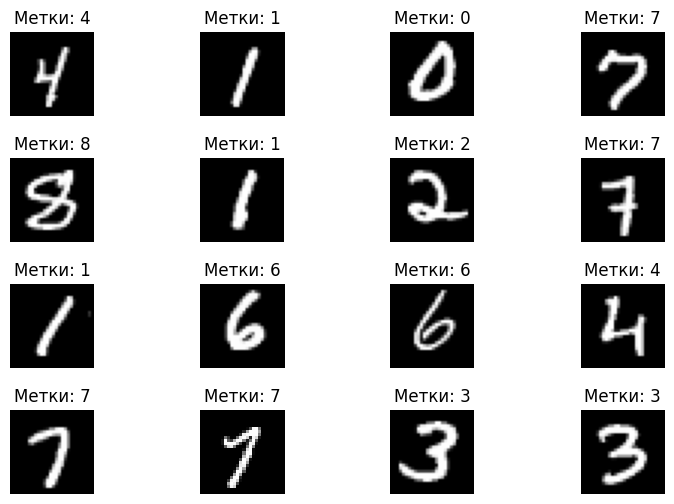

In [ ]:
x_viz, y_viz = tfds.load("mnist", split=['train[:1500]'], batch_size=-1, as_supervised=True)[0] # Взять все одним батчем и выбрать его для визуализации
print('Размерность исходных данных:', x_viz.shape)
x_viz = tf.squeeze(x_viz, axis=3) # метод сжатия размерности, исключаем данные по оси с индексом 3
print('Размерность данных после сжатия:', x_viz.shape)

for i in range(16): # Выводим 16 картинок из датасета
    plt.subplot(4,4,1+i)
    plt.axis('off')
    plt.imshow(x_viz[i], cmap='gray') # отображение массива numpy как картинки; cmap - карта цветов, используем серую 'gray'
    plt.title(f"Метки: {y_viz[i]}")
    plt.subplots_adjust(hspace=.5, wspace=.5) # Отступы по ширине и высоте между картинками


In [ ]:
# Функция изменения формы и масштабирования данных
def preprocess(x, y):
  # reshap - изменяет форму данных
  x = tf.reshape(x, shape=(-1, 784)) # -1 - значит сохранить форму для заданного индекса матрицы, равносильно указать 1500
  # Масштабируем данные
  x = x/255
  return x, y

train_data, val_data = train_data.map(preprocess), val_data.map(preprocess) # map выполняет функцию preprocess для каждого элемента данных, к которым применяется

Text(0.5, 1.0, 'Функция активации ReLU')

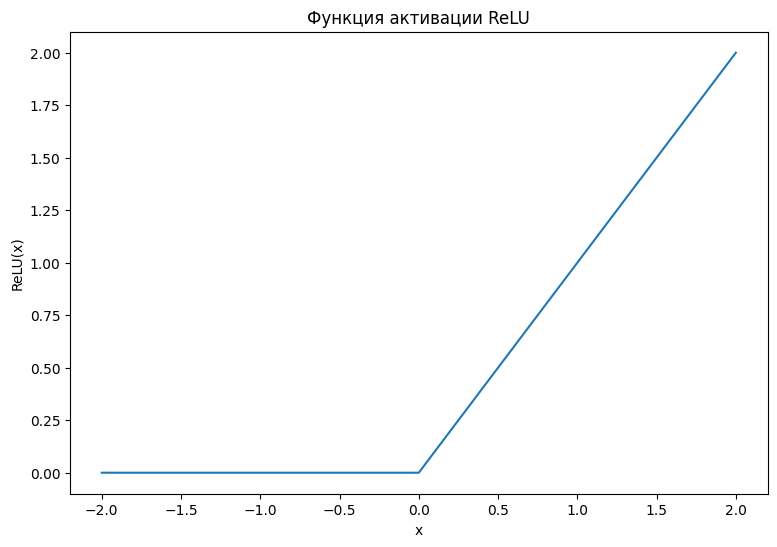

In [ ]:
x = tf.linspace(-2, 2, 201) # Тензорный вариант для linspace
x = tf.cast(x, tf.float32) # Приведение тензора к нужному типу, в данном случае к 32-х разрядному числу с плавающей точкой
plt.plot(x, tf.nn.relu(x))
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.title('Функция активации ReLU')

Text(0.5, 1.0, 'Функция активации Softmax')

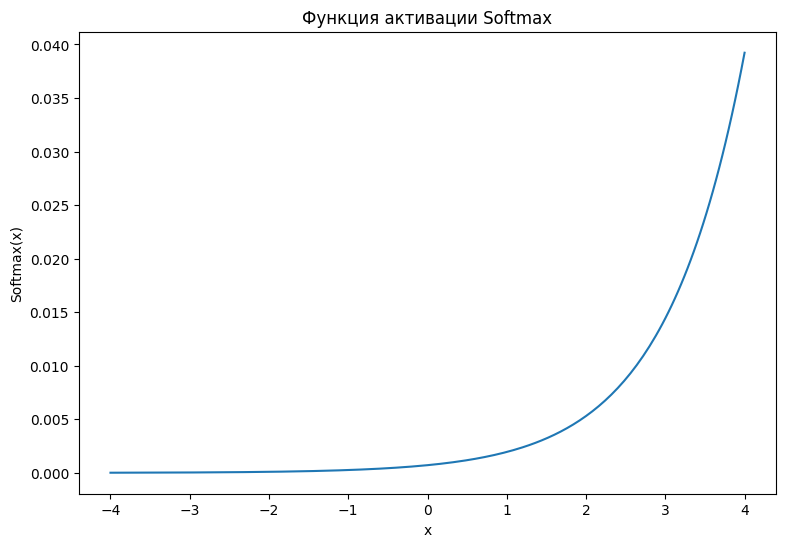

In [ ]:
x = tf.linspace(-4, 4, 201)
x = tf.cast(x, tf.float32)
plt.plot(x, tf.nn.softmax(x, axis=0)) # указываем ось (axis), индекс тензора, по которому проводим вычисления
plt.xlabel('x')
plt.ylabel('Softmax(x)')
plt.title('Функция активации Softmax')

In [ ]:
def xavier_init(shape):
  # Вычисляем значения инициализации xavier для весовой матрицы
  in_dim, out_dim = shape

  # Задаем диапазон инициализации весов по схеме Ксавье
  xavier_lim = tf.sqrt(6.)/tf.sqrt(tf.cast(in_dim + out_dim, tf.float32))

  # Возвращаем тензор с равномерно распределенными случайными величинами в указанном интервале.
  weight_vals = tf.random.uniform(shape=(in_dim, out_dim),
                                  minval=-xavier_lim, maxval=xavier_lim)
  return weight_vals

In [ ]:
class DenseLayer(tf.Module):

  def __init__(self, out_dim, weight_init=xavier_init, activation=tf.identity):
    # Инициализация размеров и функции активации
    self.out_dim = out_dim # Определяем размерность выходов
    self.weight_init = weight_init # Инициализируем веса
    self.activation = activation # Задаем функцию активации
    self.built = False

  @tf.function # Декоратор, который переносит вычисления на уровень графа TensorFlow
  def __call__(self, x):
    if not self.built: # Если запущен первый раз проводим инициализацию
      # Вывод входного измерения на основе первого вызова
      self.in_dim = x.shape[1]
      # Инициализация весов и смещений
      self.w = tf.Variable(self.weight_init(shape=(self.in_dim, self.out_dim))) # Объявление тензорных переменных
      self.b = tf.Variable(tf.zeros(shape=(self.out_dim,))) # Объявление тензорных переменных
      self.built = True # Инициализация пройдена
    # Вычисление прямого прохода
    y = tf.add(tf.matmul(x, self.w), self.b)  # уравнение персептрона
    return self.activation(y) # Применение функции активации к уравнению персептрона

In [ ]:
class MLP(tf.Module):

  def __init__(self, layers):
    self.layers = layers

  @tf.function # Декоратор, который переносит вычисления на уровень графа TensorFlow
  def __call__(self, x, preds=False):
    # Последовательное выполнение слоев модели
    for layer in self.layers:
      x = layer(x)
    return x

In [ ]:
hidden_layer_1_size = 700
hidden_layer_2_size = 500
hidden_layer_3_size = 300

output_size = 10

# Создание модели нейронной сети
mlp_model = MLP([
    DenseLayer(out_dim=hidden_layer_1_size, activation=tf.nn.relu),
    DenseLayer(out_dim=hidden_layer_2_size, activation=tf.nn.relu),
    DenseLayer(out_dim=hidden_layer_3_size, activation=tf.nn.relu),

    DenseLayer(out_dim=output_size)])

In [ ]:
def cross_entropy_loss(y_pred, y):
  # Вычисление перекрестной энтропии с помощью разреженной операции
  sparse_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=y_pred)
  return tf.reduce_mean(sparse_ce) # аналог np.mean для тензоров

In [ ]:
def accuracy(y_pred, y):
  # Вычисляем точность после извлечения предсказаний класса
  class_preds = tf.argmax(tf.nn.softmax(y_pred), axis=1) # возвращает индекс максимального элемента
  is_equal = tf.equal(y, class_preds) # сравнение тензорных значений
  return tf.reduce_mean(tf.cast(is_equal, tf.float32)) # аналог np.mean для тензоров

In [ ]:
class Adam:

    def __init__(self, learning_rate=1e-3, beta_1=0.9, beta_2=0.999, ep=1e-7):
      # Инициализируем параметры оптимизатора и резервируем переменные
      self.beta_1 = beta_1 # гиперпараметр
      self.beta_2 = beta_2 # гиперпараметр
      self.learning_rate = learning_rate # шаг обучения
      self.ep = ep # Эпсилон - предотвращает деление на ноль, слабо влияет на обучение
      self.t = 1.
      self.v_dvar, self.s_dvar = [], []
      self.built = False

    def apply_gradients(self, grads, vars):
      # Инициализируем переменные при первом вызове
      if not self.built:
        for var in vars:
          v = tf.Variable(tf.zeros(shape=var.shape))
          s = tf.Variable(tf.zeros(shape=var.shape))
          self.v_dvar.append(v)
          self.s_dvar.append(s)
        self.built = True
      # Обновите переменные модели с учетом их градиентов
      for i, (d_var, var) in enumerate(zip(grads, vars)):
        self.v_dvar[i].assign(self.beta_1*self.v_dvar[i] + (1-self.beta_1)*d_var)
        self.s_dvar[i].assign(self.beta_2*self.s_dvar[i] + (1-self.beta_2)*tf.square(d_var))
        v_dvar_bc = self.v_dvar[i]/(1-(self.beta_1**self.t))
        s_dvar_bc = self.s_dvar[i]/(1-(self.beta_2**self.t))
        var.assign_sub(self.learning_rate*(v_dvar_bc/(tf.sqrt(s_dvar_bc) + self.ep)))
      self.t += 1.
      return

In [ ]:
def train_step(x_batch, y_batch, loss, acc, model, optimizer):
  # Обновляем состояние модели с учетом пакета данных
  with tf.GradientTape() as tape:
    y_pred = model(x_batch) # Предсказываем значение с текущими весами
    batch_loss = loss(y_pred, y_batch) # Оцениваем ошибку на текущих весах
  batch_acc = acc(y_pred, y_batch) # Оцениваем точность на текущих весах
  grads = tape.gradient(batch_loss, model.variables) # Вычисляем градиенты
  optimizer.apply_gradients(grads, model.variables) # Обновляем переменные с учетом полученных градиентов
  return batch_loss, batch_acc # Возвращаем ошибку и точность на основе заданного пакета

def val_step(x_batch, y_batch, loss, acc, model):
  # Оцениваем модель на основе заданного пакета валидационных данных без обучения на текущих весах
  y_pred = model(x_batch)
  batch_loss = loss(y_pred, y_batch)
  batch_acc = acc(y_pred, y_batch)
  return batch_loss, batch_acc

In [ ]:
def train_model(mlp, train_data, val_data, loss, acc, optimizer, epochs):
  # Инициализация структур данных
  train_losses, train_accs = [], []
  val_losses, val_accs = [], []

  # Отформатируем тренировочный цикл и начнем обучение
  for epoch in range(epochs):
    batch_losses_train, batch_accs_train = [], []
    batch_losses_val, batch_accs_val = [], []

    # Выполняем итерацию по обучающим данным
    for x_batch, y_batch in train_data:
      # Вычисляем градиенты и обновляем параметры модели
      batch_loss, batch_acc = train_step(x_batch, y_batch, loss, acc, mlp, optimizer)
      # Следим за результатами обучения на пакетном уровне
      batch_losses_train.append(batch_loss)
      batch_accs_train.append(batch_acc)

    # Повторяем процедуру проверки данных
    for x_batch, y_batch in val_data:
      batch_loss, batch_acc = val_step(x_batch, y_batch, loss, acc, mlp)
      batch_losses_val.append(batch_loss)
      batch_accs_val.append(batch_acc)

    # Следим за производительностью модели на уровне эпохи
    train_loss, train_acc = tf.reduce_mean(batch_losses_train), tf.reduce_mean(batch_accs_train)
    val_loss, val_acc = tf.reduce_mean(batch_losses_val), tf.reduce_mean(batch_accs_val)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f"Эпоха: {epoch}")
    print(f"Обучающая ошибка: {train_loss:.3f}, Обучающая точность: {train_acc:.3f}")
    print(f"Валидационная ошибка: {val_loss:.3f}, Валидационная точность: {val_acc:.3f}")
  return train_losses, train_accs, val_losses, val_accs

In [ ]:
train_losses, train_accs, val_losses, val_accs = train_model(mlp_model, train_data, val_data,
                                                             loss=cross_entropy_loss, acc=accuracy,
                                                             optimizer=Adam(), epochs=10)

Эпоха: 0
Обучающая ошибка: 0.018, Обучающая точность: 0.994
Валидационная ошибка: 0.111, Валидационная точность: 0.980
Эпоха: 1
Обучающая ошибка: 0.016, Обучающая точность: 0.995
Валидационная ошибка: 0.119, Валидационная точность: 0.977
Эпоха: 2
Обучающая ошибка: 0.014, Обучающая точность: 0.996
Валидационная ошибка: 0.106, Валидационная точность: 0.979
Эпоха: 3
Обучающая ошибка: 0.012, Обучающая точность: 0.996
Валидационная ошибка: 0.126, Валидационная точность: 0.978
Эпоха: 4
Обучающая ошибка: 0.014, Обучающая точность: 0.995
Валидационная ошибка: 0.124, Валидационная точность: 0.976
Эпоха: 5
Обучающая ошибка: 0.010, Обучающая точность: 0.997
Валидационная ошибка: 0.114, Валидационная точность: 0.979
Эпоха: 6
Обучающая ошибка: 0.007, Обучающая точность: 0.998
Валидационная ошибка: 0.112, Валидационная точность: 0.983
Эпоха: 7
Обучающая ошибка: 0.013, Обучающая точность: 0.996
Валидационная ошибка: 0.117, Валидационная точность: 0.977
Эпоха: 8
Обучающая ошибка: 0.008, Обучающая точн

In [ ]:
def plot_metrics(train_metric, val_metric, metric_type):
  # Визуализация метрик в зависимости от эпох обучения
  plt.figure()
  plt.plot(range(len(train_metric)), train_metric, label = f"{metric_type} на обучающей выборке")
  plt.plot(range(len(val_metric)), val_metric, label = f"{metric_type} на валидационной выборке")
  plt.xlabel("Эпохи")
  plt.ylabel(metric_type)
  plt.legend()
  plt.title(f"{metric_type} от эпохи");

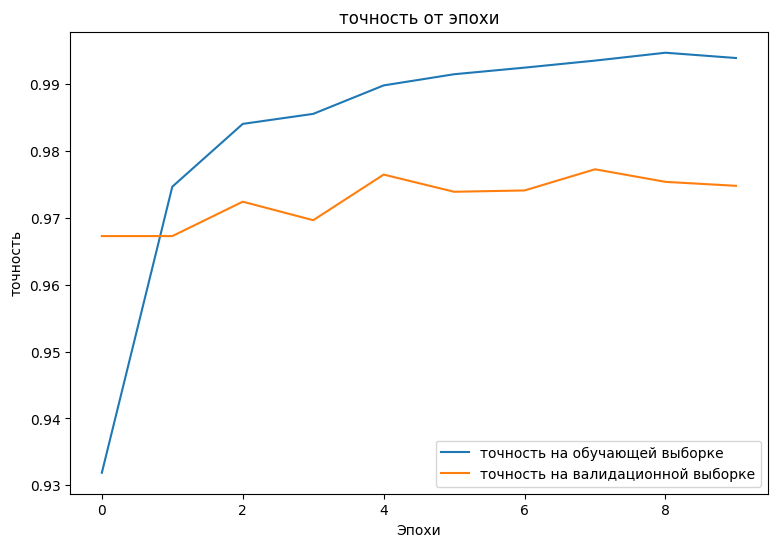

In [ ]:
plot_metrics(train_accs, val_accs, "точность")

In [ ]:
class ExportModule(tf.Module):
  def __init__(self, model, preprocess, class_pred):
    # Инициализация функций предобработки и постобработки
    self.model = model
    self.preprocess = preprocess
    self.class_pred = class_pred

  @tf.function(input_signature=[tf.TensorSpec(shape=[None, None, None, None], dtype=tf.uint8)])
  def __call__(self, x):
    # Запускаем модуль экспорта для получения новых точек данных
    x = self.preprocess(x)
    y = self.model(x)
    y = self.class_pred(y)
    return y

In [ ]:
def preprocess_test(x):
  # Модуль экспорта принимает необработанные и немаркированные данные
  x = tf.reshape(x, shape=[-1, 784])
  x = x/255
  return x

def class_pred_test(y):
  # Сгенерируем прогнозы классов на основе выходных данных MLP
  return tf.argmax(tf.nn.softmax(y), axis=1)

In [ ]:
mlp_model_export = ExportModule(model=mlp_model,
                                preprocess=preprocess_test,
                                class_pred=class_pred_test)

In [ ]:
models = tempfile.mkdtemp()
save_path = os.path.join(models, 'mlp_model_export')
tf.saved_model.save(mlp_model_export, save_path)

In [ ]:
mlp_loaded = tf.saved_model.load(save_path)

In [ ]:
def accuracy_score(y_pred, y):
  # Общая функция точности
  is_equal = tf.equal(y_pred, y)
  return tf.reduce_mean(tf.cast(is_equal, tf.float32))

x_test, y_test = tfds.load("mnist", split=['test'], batch_size=-1, as_supervised=True)[0]
test_classes = mlp_loaded(x_test)
test_acc = accuracy_score(test_classes, y_test)
print(f"Точность на тестовой выборке: {test_acc:.3f}")

Точность на тестовой выборке: 0.974


In [ ]:
print("Точность с разбивкой по цифрам :")
print("---------------------------")
label_accs = {}
for label in range(10):
  label_ind = (y_test == label)
  # extract predictions for specific true label
  pred_label = test_classes[label_ind]
  labels = y_test[label_ind]
  # compute class-wise accuracy
  label_accs[accuracy_score(pred_label, labels).numpy()] = label
for key in sorted(label_accs):
  print(f"Цифра {label_accs[key]}: {key:.3f}")

Точность с разбивкой по цифрам :
---------------------------
Цифра 2: 0.953
Цифра 8: 0.954
Цифра 4: 0.955
Цифра 7: 0.973
Цифра 5: 0.975
Цифра 3: 0.977
Цифра 9: 0.983
Цифра 6: 0.984
Цифра 0: 0.989
Цифра 1: 0.996


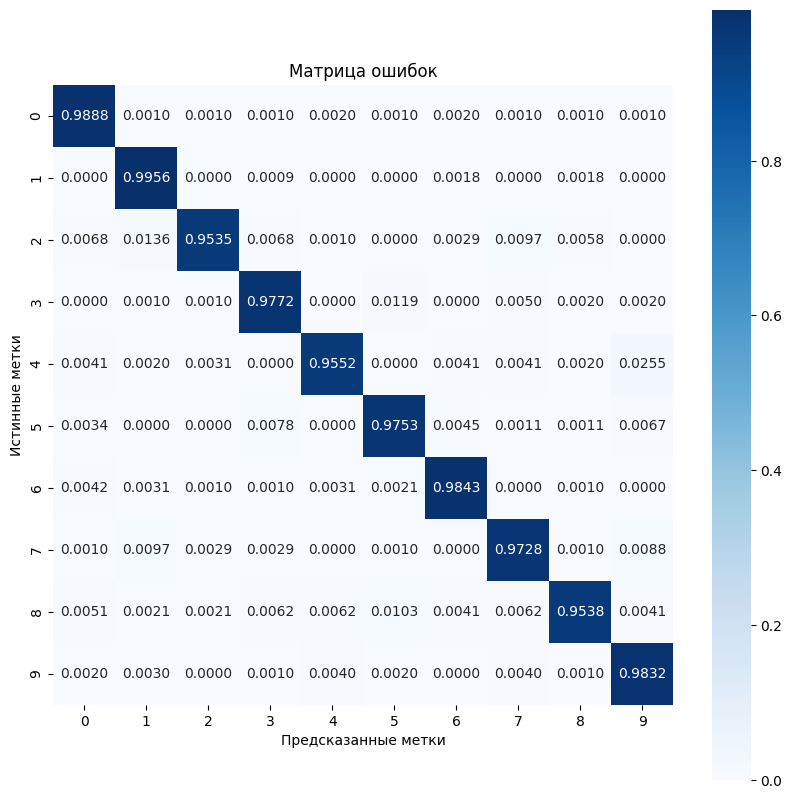

In [ ]:
import sklearn.metrics as sk_metrics

def show_confusion_matrix(test_labels, test_classes):
  # Вычисление матрицы ошибок и ее нормализация
  plt.figure(figsize=(10,10))
  confusion = sk_metrics.confusion_matrix(test_labels.numpy(),
                                          test_classes.numpy())
  confusion_normalized = confusion / confusion.sum(axis=1, keepdims=True)
  axis_labels = range(10)
  ax = sns.heatmap(
      confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels,
      cmap='Blues', annot=True, fmt='.4f', square=True)
  plt.title("Матрица ошибок")
  plt.ylabel("Истинные метки")
  plt.xlabel("Предсказанные метки")

show_confusion_matrix(y_test, test_classes)

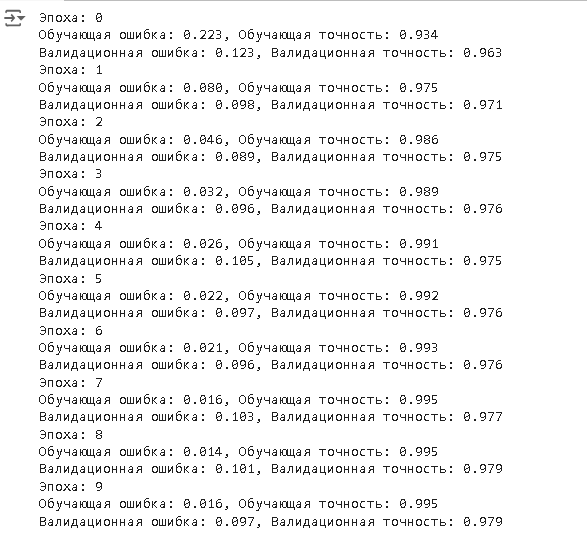

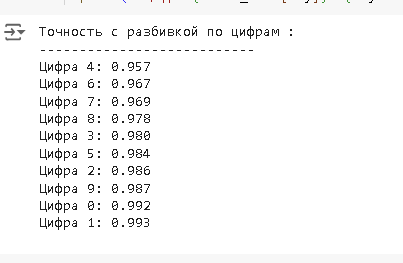

Резульататы 3 слоя.

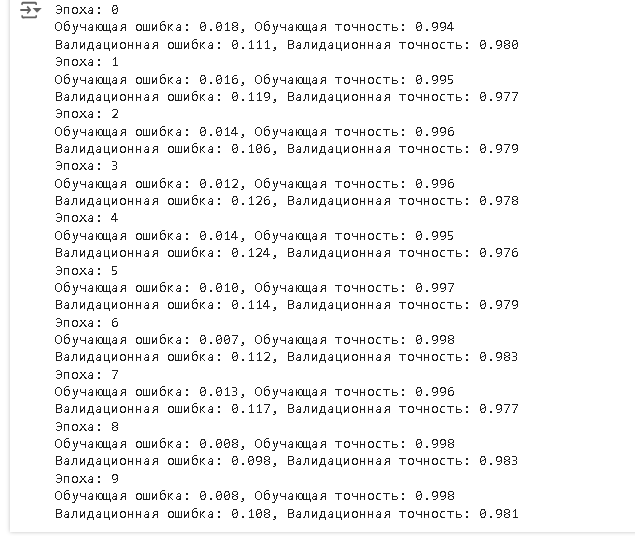

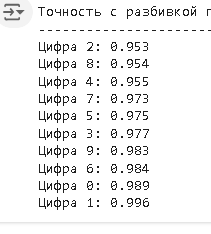

Результат сравнения, точность и обучаемость модели выросла.

Задание 2-го уровня сложности

Обучите модель. В качестве датасета можете использовать любой из наборов данных TensorFlow, но отличный от MNIST, который был в уроке.

Добейтесь результата распознавания более 85% на тестовой выборке.

Напишите ваше решение в Сolab и вышлите на проверку своему куратору.
Датасеты на выбор.

Критерии оценивания
Код работает корректно
Результат распознавания более 85% на тестовой выборке

Я выбрал Датасет о цветении вишневых деревьев в городе Киото.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Загрузка данных
train_data, val_data = tfds.load("cherry_blossoms",
                                   split=['train[:80%]', 'train[80%:]'],
                                   batch_size=128,
                                   as_supervised=False)

# Препроцессинг данных
def preprocess(features):
    features_tensor = tf.stack([
        features['doy'],
        features['temp'],
        features['temp_lower'],
        features['temp_upper'],
        tf.cast(features['year'], tf.float32)  # преобразуем year в float
    ], axis=1)

    labels = features['doy']  # Целевая переменная
    return features_tensor, labels

# Фильтрация NaN и Inf
def filter_nan_inf(features, labels):
    # Объединим информацию о NaNs и Infs по всем входным данным
    valid_mask = tf.reduce_all(tf.math.is_finite(features), axis=1)  # Подходит для всех значений
    return tf.boolean_mask(features, valid_mask), tf.boolean_mask(labels, valid_mask)

# Применяем обработку данных и фильтрацию
train_data = train_data.map(preprocess).map(filter_nan_inf).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(preprocess).map(filter_nan_inf).prefetch(tf.data.AUTOTUNE)

# Теперь train_data и val_data не содержат NaN или Inf значений


In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [ ]:
import tensorflow as tf

class DenseLayer(tf.Module):
    def __init__(self, out_dim, weight_init=tf.keras.initializers.GlorotUniform(), activation=tf.identity):
        super(DenseLayer, self).__init__()  # Вызов конструктора базового класса
        self.out_dim = out_dim
        self.weight_init = weight_init
        self.activation = activation
        self.built = False

    @tf.function
    def __call__(self, x):
        if not self.built:
            self.in_dim = x.shape[1]
            # Используем инициализатор для создания весов
            self.w = tf.Variable(self.weight_init(shape=(self.in_dim, self.out_dim)), trainable=True)
            self.b = tf.Variable(tf.zeros(shape=(self.out_dim,)), trainable=True)
            self.built = True
        # Линейная комбинация + активация
        y = tf.add(tf.matmul(x, self.w), self.b)
        return self.activation(y)

class SequentialModel(tf.keras.Model):
    def __init__(self, layer_sizes):
        super(SequentialModel, self).__init__()
        self.layers_list = []
        for size in layer_sizes:
            self.layers_list.append(tf.keras.layers.Dense(size, activation='relu'))
        self.layers_list.append(tf.keras.layers.Dense(1))  # Слой для выхода с одним значением

    def call(self, x):
        for layer in self.layers_list:
            x = layer(x)
        return x



In [ ]:
import tensorflow as tf

def accuracy(y_pred, y):
    class_preds = tf.argmax(tf.nn.softmax(y_pred), axis=1)
    is_equal = tf.equal(y, class_preds)
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

# Оптимизатор Adam
class Adam:
    def __init__(self, learning_rate=1e-3, beta_1=0.9, beta_2=0.999, ep=1e-7):
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.learning_rate = learning_rate
        self.ep = ep
        self.t = 1.
        self.v_dvar, self.s_dvar = [], []
        self.built = False

    def apply_gradients(self, grads, vars):
        if not self.built:
            for var in vars:
                v = tf.Variable(tf.zeros(shape=var.shape))
                s = tf.Variable(tf.zeros(shape=var.shape))
                self.v_dvar.append(v)
                self.s_dvar.append(s)
            self.built = True
        for i, (d_var, var) in enumerate(zip(grads, vars)):
            self.v_dvar[i].assign(self.beta_1 * self.v_dvar[i] + (1 - self.beta_1) * d_var)
            self.s_dvar[i].assign(self.beta_2 * self.s_dvar[i] + (1 - self.beta_2) * tf.square(d_var))
            v_dvar_bc = self.v_dvar[i] / (1 - (self.beta_1 ** self.t))
            s_dvar_bc = self.s_dvar[i] / (1 - (self.beta_2 ** self.t))
            var.assign_sub(self.learning_rate * (v_dvar_bc / (tf.sqrt(s_dvar_bc) + self.ep)))
        self.t += 1.


In [ ]:
def train_step(x_batch, y_batch, loss_fn, accuracy_fn, model, optimizer):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch)  # Получаем предсказания модели
        batch_loss = loss_fn(y_pred, y_batch)  # Вычисляем потерю
        batch_acc = accuracy_fn(y_pred, y_batch)  # Вычисляем точность
    grads = tape.gradient(batch_loss, model.trainable_variables)  # Вычисляем градиенты
    optimizer.apply_gradients(zip(grads, model.trainable_variables))  # Обновляем параметры модели
    return batch_loss, batch_acc


In [ ]:
def val_step(x_batch, y_batch, loss_fn, accuracy_fn, model):
    y_pred = model(x_batch)  # Получаем предсказания модели на валидационном наборе
    batch_loss = loss_fn(y_pred, y_batch)  # Вычисляем потерю
    batch_acc = accuracy_fn(y_pred, y_batch)  # Вычисляем точность
    return batch_loss, batch_acc


In [ ]:
def train_model(mlp, train_data, val_data, loss_fn, optimizer, epochs):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        batch_losses_train = []
        batch_losses_val = []

        # Обучающая часть
        for features, labels in train_data:
            # В features уже содержится тензор с фичами размерности (None, 5)
            x_batch = features
            y_batch = tf.cast(labels, tf.float32)  # Приводим к форме float для регрессии

            # Выполнение шага обучения
            with tf.GradientTape() as tape:
                predictions = mlp(x_batch)
                batch_loss = loss_fn(y_batch, predictions)
            gradients = tape.gradient(batch_loss, mlp.trainable_variables)
            optimizer.apply_gradients(zip(gradients, mlp.trainable_variables))

            batch_losses_train.append(batch_loss)

        # Валидация
        for features, labels in val_data:
            x_batch = features  # Используем тот же формат данных
            y_batch = tf.cast(labels, tf.float32)  # Приводим к форме float для регрессии
            predictions = mlp(x_batch)
            batch_loss = loss_fn(y_batch, predictions)
            batch_losses_val.append(batch_loss)

        # Собираем метрики
        train_loss = tf.reduce_mean(batch_losses_train)
        val_loss = tf.reduce_mean(batch_losses_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Выводим результаты для эпохи
        print(f"Эпоха: {epoch + 1}, "
              f"Обучающая ошибка: {train_loss:.3f}, "
              f"Валидационная ошибка: {val_loss:.3f}")

    return train_losses, val_losses

# Инициализация и обучение модели
mlp_model = SequentialModel(layer_sizes=[64, 32, 16, 10])
train_losses, val_losses = train_model(
    mlp_model,
    train_data,
    val_data,
    loss_fn=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(),
    epochs=100
)


Эпоха: 1, Обучающая ошибка: 7637.216, Валидационная ошибка: 2133.438
Эпоха: 2, Обучающая ошибка: 848.280, Валидационная ошибка: 619.652
Эпоха: 3, Обучающая ошибка: 792.132, Валидационная ошибка: 625.360
Эпоха: 4, Обучающая ошибка: 462.547, Валидационная ошибка: 540.235
Эпоха: 5, Обучающая ошибка: 465.376, Валидационная ошибка: 517.071
Эпоха: 6, Обучающая ошибка: 386.976, Валидационная ошибка: 446.128
Эпоха: 7, Обучающая ошибка: 393.230, Валидационная ошибка: 438.419
Эпоха: 8, Обучающая ошибка: 376.231, Валидационная ошибка: 455.550
Эпоха: 9, Обучающая ошибка: 371.554, Валидационная ошибка: 434.682
Эпоха: 10, Обучающая ошибка: 367.087, Валидационная ошибка: 429.203
Эпоха: 11, Обучающая ошибка: 364.117, Валидационная ошибка: 431.474
Эпоха: 12, Обучающая ошибка: 360.256, Валидационная ошибка: 424.603
Эпоха: 13, Обучающая ошибка: 356.749, Валидационная ошибка: 419.516
Эпоха: 14, Обучающая ошибка: 353.558, Валидационная ошибка: 417.226
Эпоха: 15, Обучающая ошибка: 349.769, Валидационная оши

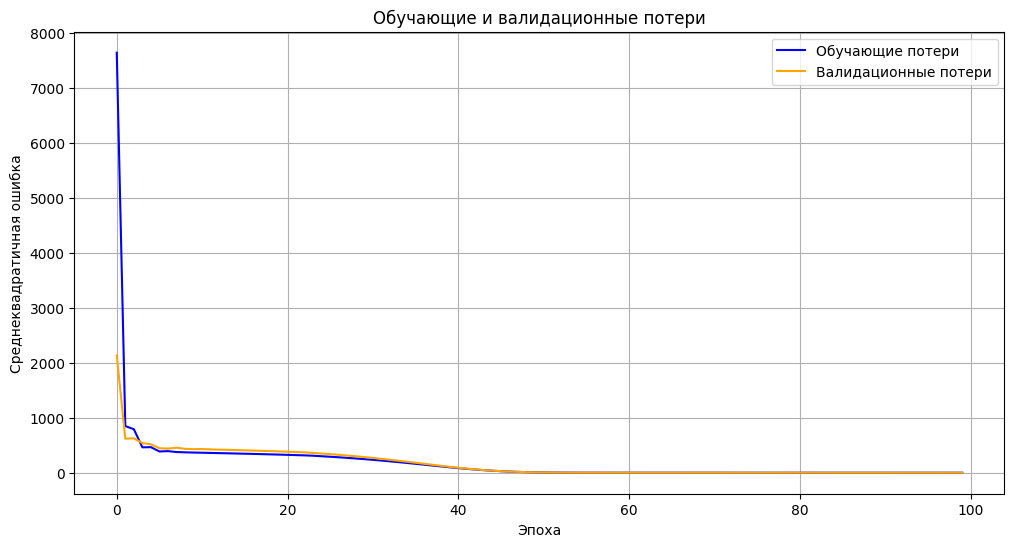

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, label='Обучающие потери', color='blue')
    plt.plot(val_losses, label='Валидационные потери', color='orange')
    plt.title('Обучающие и валидационные потери')
    plt.xlabel('Эпоха')
    plt.ylabel('Среднеквадратичная ошибка')
    plt.legend()
    plt.grid()
    plt.show()

# После обучения модели
plot_losses(train_losses, val_losses)


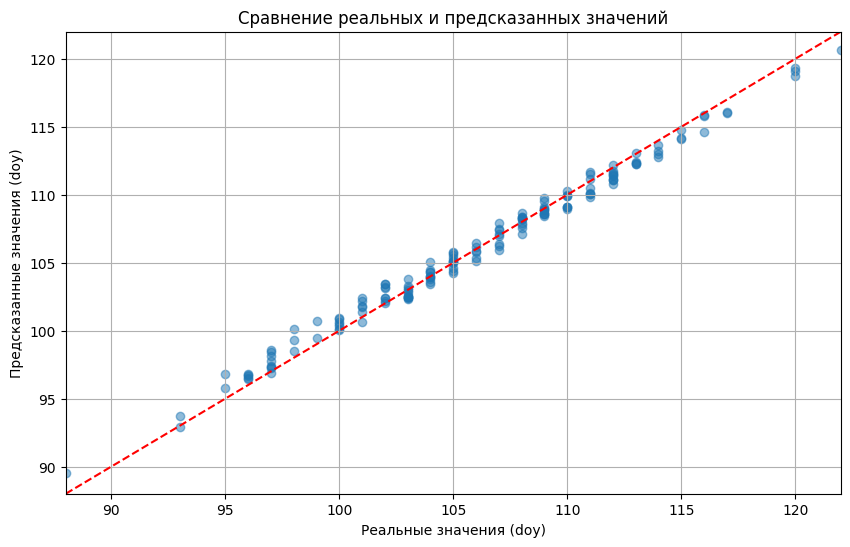

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Получаем предсказания для валидационного набора данных
predictions = []
actuals = []

for features, labels in val_data:
    # Получаем предсказания от модели
    preds = mlp_model(features)
    predictions.append(preds.numpy())  # Конвертируем тензор в numpy массив
    actuals.append(labels.numpy())  # Конвертируем тензор в numpy массив

# Преобразуем списки в одномерные массивы
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(actuals, predictions, alpha=0.5)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')  # Линия y=x
plt.title('Сравнение реальных и предсказанных значений')
plt.xlabel('Реальные значения (doy)')
plt.ylabel('Предсказанные значения (doy)')
plt.xlim([actuals.min(), actuals.max()])
plt.ylim([actuals.min(), actuals.max()])
plt.grid(True)
plt.show()


Точки на графике: Каждая точка на графике представляет собой пару (реальное значение, предсказанное значение). Если модель предсказывает правильно, точки должны располагаться близко к красной линии (y=x), что означает, что предсказанные значения хорошо совпадают с реальными.

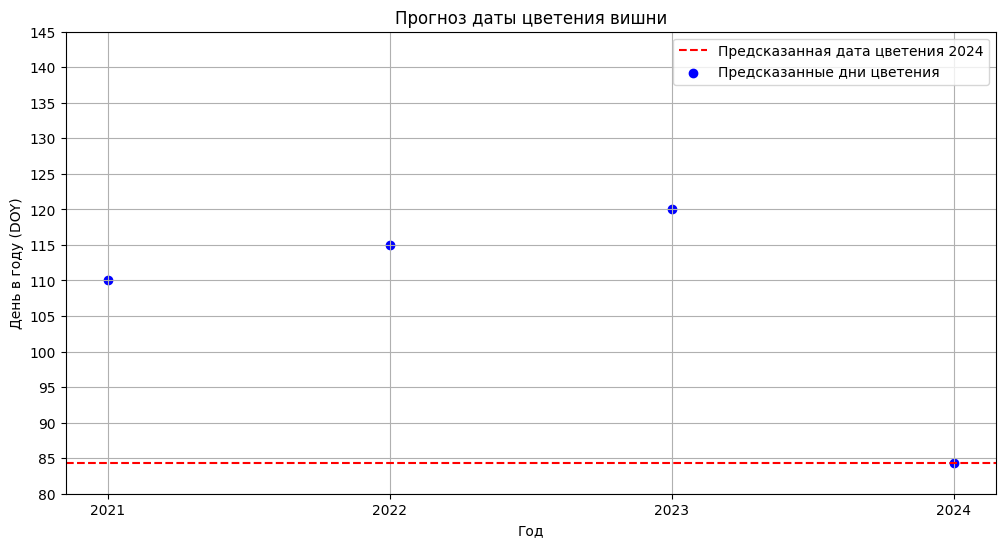

Предсказанная дата цветения вишни на 2024 год (DOY): 84.4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Допустим, у нас есть данные о температуре на основе исторических данных
historical_data = {
    'year': [2021, 2022, 2023],
    'predicted_flowering_day': [110, 115, 120]  # Пример предсказанных дней цветения
}

# Препроцессим данные будущего года для прогноза
future_data = pd.DataFrame({
    'temp': [15.0],  # средняя температура
    'temp_lower': [10.0],  # нижний предел
    'temp_upper': [20.0],  # верхний предел
    'year': [2024],  # год
    'doy' : [1]

})

# Препроцессинг
future_data_tensor = tf.convert_to_tensor(future_data.values, dtype=tf.float32)

# Вводим функцию для предсказания цвета
predicted_flowering_day = mlp_model(future_data_tensor).numpy()[0][0]  # Получаем предсказание для следующего года

# Добавим новое предсказание в исторические данные
historical_data['year'].append(2024)
historical_data['predicted_flowering_day'].append(predicted_flowering_day)

# Преобразуем в DataFrame
historical_flowering_data = pd.DataFrame(historical_data)

# Визуализация
plt.figure(figsize=(12, 6))
plt.title("Прогноз даты цветения вишни")
plt.xlabel("Год")
plt.ylabel("День в году (DOY)")
plt.axhline(y=predicted_flowering_day, color='r', linestyle='--', label='Предсказанная дата цветения 2024')
plt.scatter(historical_flowering_data['year'], historical_flowering_data['predicted_flowering_day'], color='blue', label='Предсказанные дни цветения')
plt.xticks(np.arange(2021, 2025, 1))
plt.yticks(np.arange(80, 150, 5))
plt.legend()
plt.grid()
plt.show()

print(f"Предсказанная дата цветения вишни на 2024 год (DOY): {predicted_flowering_day:.1f}")


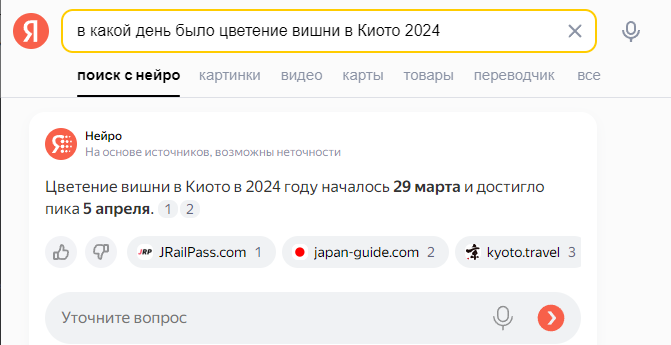

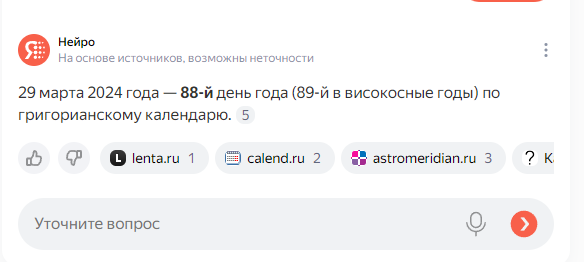